# Section I. Research

### Load libraries, functions, palette, theme

In [1]:
import os
from pathlib import Path

In [2]:
# load libraries and palette
%run __libraries.ipynb

In [3]:
# load functions
# from __functions import *
%run __functions.ipynb

In [4]:
# start stopwatch
start = stopwatch_start()

### Variables

In [5]:
dir_current = '01-explore'

In [6]:
dir_save_img = 'docs/img/' + dir_current

## Load Data

In [7]:
data_raw = pd.read_csv('data-raw/' + 'creditcard.csv')

In [8]:
data_raw.shape

(284807, 31)

#### Remove duplicates

In [9]:
# duplicated rows
len(data_raw[data_raw.duplicated()])

1081

In [10]:
# duplicates total
len(data_raw[data_raw.duplicated(keep=False)])

1854

In [11]:
data_raw = data_raw.drop_duplicates()

In [12]:
data_raw.shape

(283726, 31)

#### Actual data_raw

In [13]:
data_raw.shape

(283726, 31)

In [14]:
print(data_raw.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [15]:
data_raw.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [16]:
data_raw['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [17]:
data_raw['Class'].mean()

0.001667101358352777

## Train Test Split

In [18]:
train_last_idx = 224864

In [19]:
data_train = data_raw.loc[:train_last_idx, :].copy()

In [20]:
data_train.shape

(224036, 31)

In [21]:
data_test = data_raw[train_last_idx:].copy()

In [22]:
data_test.shape

(58862, 31)

In [23]:
data_test.shape[0] / data_raw.shape[0]

0.20746071914452677

In [24]:
data_test.shape[0] / data_train.shape[0]

0.26273456051705973

# Data Explore

In [25]:
data = data_train.copy()

In [26]:
data.shape

(224036, 31)

### Additional Variables and Datasets

##### Variables

In [27]:
target = 'Class'

In [28]:
features = (data
           .drop([target], axis=1)
           .select_dtypes(include=['int64', 'float64'])
           .columns.tolist())

In [29]:
len(features)

30

In [30]:
assert len(data.columns) == len(features) + 1

##### Datasets

In [31]:
cleans, frauds = update_cleans_and_frauds(data)

In [32]:
cleans_sample = cleans[::500].copy()

In [33]:
cleans_sample_random_ratio = 0.7

In [34]:
cleans_sample_random_length = math.floor(len(frauds)/cleans_sample_random_ratio)
cleans_sample_random = cleans.sample(n=cleans_sample_random_length)

#### Remove transations with 'Amount' == 0

### Features: Missing Values Handling

No NaN values

In [35]:
df_missing_values = data_describe(data[features])

In [36]:
df_missing_values.head(5)

,Type,Count,Unique,NaN,Percentages
Time,float64,224036,99753,0,0
V1,float64,224036,218311,0,0
V2,float64,224036,218311,0,0
V3,float64,224036,218311,0,0
V4,float64,224036,218311,0,0


In [37]:
df_missing_values.loc['Time', 'Unique'] / df_missing_values.loc['Time', 'Count']

0.4452543341248728

## Time variable

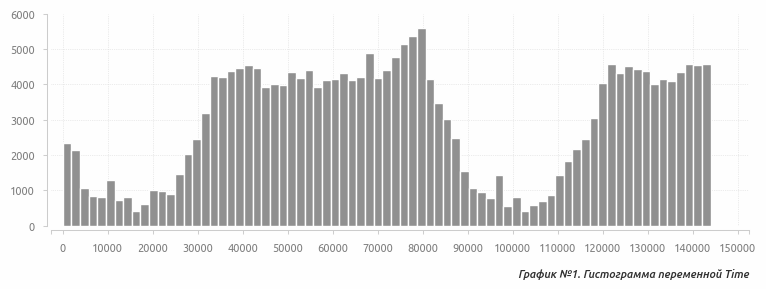

Image 'time_hist.png' successfully saved into 'docs/img/01-explore' directory


In [38]:
fig, ax = plt.subplots()

ax.hist(
    x=data['Time'],
    bins=75,
    color=palette[-2],
    **hist
)

ax.set_xticks(arange(0, 150000, 10000, True))
axis_add_interval_to_first_last_ticks(0.25)

axis_rstyle(grid=True)

# ticklabels = ax.xaxis.get_ticklabels()
# for i, ticklabel in enumerate(ticklabels):
#     if (i % 2 != 0) & (i != 1):
#         ticklabel.set_visible(False)

# ax.set_ylabel('Count', **label)
# ax.set_xlabel('Seconds', **label)

ax.annotate(
    'График №1. Гистограмма переменной Time',
    xy=(1, -0.2),
    **annotation
)

plt.show()

savefig('time_hist', dir_save_img, format='png')

##### Transactions per time unit

In [39]:
data['Time'].value_counts()

Time
3767.0      21
3770.0      20
3750.0      19
19912.0     19
3749.0      17
            ..
143980.0     1
143982.0     1
143983.0     1
143989.0     1
143994.0     1
Name: count, Length: 99753, dtype: int64

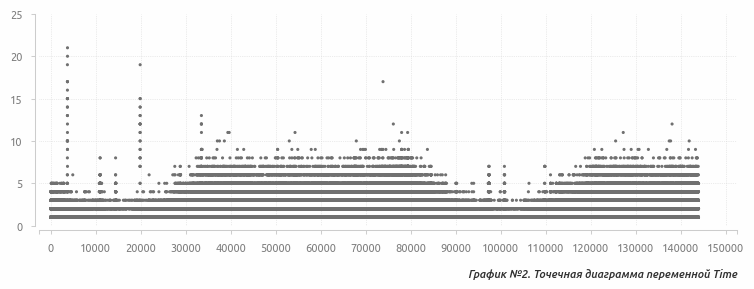

Image 'time_scatter.png' successfully saved into 'docs/img/01-explore' directory


In [40]:
fig, ax = plt.subplots()
# fig, ax = plt.subplots(figsize=(9, 3))

ax.scatter(
    data['Time'].value_counts().index,
    data['Time'].value_counts(),
    edgecolors='none',
    color=palette[-3],
    s=5,
    **scatter
)

ax.set_xticks(arange(0, 150000, 10000, True))
ax.set_yticks(arange(0, 30, 5))

axis_add_interval_to_first_last_ticks(0.25)
axis_rstyle(grid=True)

ax.annotate(
    'График №2. Точечная диаграмма переменной Time',
    xy=(1, -0.2),
    **annotation
)

plt.show()

savefig('time_scatter', dir_save_img, format='png')

#### Time variables formatted

Assumption: minimum transactions is around 0:00 hours.  
Assumption: 14400 time units equivalents 0:00:00 hours, then 0 time units equivalents 20:00:00 hours.

##### <font color='#CE4F44'>Variable:</font> TimeSecondOfDay

In [41]:
seconds_in_day = 86400

In [42]:
hypothetical_twilight = 15000

In [43]:
hypothetical_first_transaction_second = seconds_in_day - hypothetical_twilight

In [44]:
hypothetical_first_transaction_time = dt.timedelta(
    seconds=hypothetical_first_transaction_second
)

In [45]:
hypothetical_first_transaction_time = str(hypothetical_first_transaction_time)

In [46]:
hypothetical_first_transaction_time

'19:50:00'

In [47]:
second_of_day_delta = 14400

In [48]:
data['TimeSecondOfDay'] = data['Time'].copy()

In [49]:
data['TimeSecondOfDay'] -= second_of_day_delta

In [50]:
data['TimeSecondOfDay'] = data['TimeSecondOfDay'].apply(lambda x: time_variable_transform(x, 0, seconds_in_day))

##### <font color='#CE4F44'>Variable:</font> TimeTimestamp

In [51]:
timestamp_delta = data['TimeSecondOfDay'].iloc[0]

In [52]:
timestamp_delta

72000.0

In [53]:
data['TimeTimestamp'] = data['Time'].copy()
data['TimeTimestamp'] += timestamp_delta

##### <font color='#CE4F44'>Variable:</font> TimeDatetime

In [54]:
data['TimeDatetime'] = pd.to_datetime(data['TimeTimestamp'], unit='s')
data['TimeDatetime'] = data['TimeDatetime'].apply(lambda x: x.replace(year=2024, month=6) + dt.timedelta(days=5))

In [55]:
data['TimeDatetime']

0        2024-06-06 20:00:00
1        2024-06-06 20:00:00
2        2024-06-06 20:00:01
3        2024-06-06 20:00:01
4        2024-06-06 20:00:02
                 ...        
224860   2024-06-08 11:59:58
224861   2024-06-08 11:59:58
224862   2024-06-08 11:59:58
224863   2024-06-08 11:59:59
224864   2024-06-08 11:59:59
Name: TimeDatetime, Length: 224036, dtype: datetime64[us]

##### <font color='#CE4F44'>Variable:</font> TimeMinute, TimeHour

In [56]:
data['TimeMinute'] = data['TimeDatetime'].dt.minute

In [57]:
data['TimeHour'] = data['TimeDatetime'].dt.hour

##### <font color='#CE4F44'>Variable:</font> TimeFromLastTransaction

In [58]:
data['TimeFromLastTransaction'] = data['Time'].diff().fillna(0)

##### <font color='#1E82C8'>Variable:</font> Update Cleans and Frauds

In [59]:
cleans, frauds = update_cleans_and_frauds(data)

##### <font color='#40996D'>Variable:</font> Visualization 

In [60]:
df_time_datetime_count = data.groupby(pd.Grouper(key='TimeDatetime', freq='30min'))['Time'].count()

In [61]:
df_time_datetime_count.head()

TimeDatetime
2024-06-06 20:00:00    2244
2024-06-06 20:30:00    1687
2024-06-06 21:00:00    1457
2024-06-06 21:30:00     756
2024-06-06 22:00:00     751
Freq: 30min, Name: Time, dtype: int64

/var/folders/2_/z4vwl3gj4l3g3wd030nf35n00000gn/T/ipykernel_2273/1363426481.py:3995: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['День 1', 'День 2'])


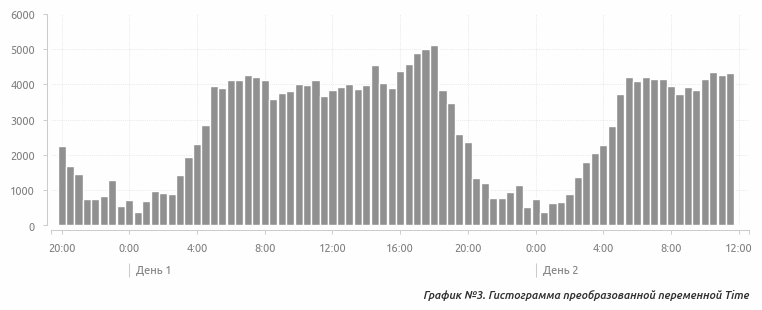

Image 'time_datetime_hist.png' successfully saved into 'docs/img/01-explore' directory


In [62]:
fig, ax = plt.subplots()

ax.bar(
    x=df_time_datetime_count.index,
    height=df_time_datetime_count,
    color=palette[-2],
    width=0.02
)

ax.xaxis.set_major_locator(mpl.dates.HourLocator(byhour=arange(0, 24, 4)))
# ax.xaxis.set_major_locator(mpl.dates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter(fmt='%-H:%M'))

# ax.set_xticks(ax.get_xticks()[1:-1])

add_days_labels(ax=ax)

axis_add_interval_to_first_last_ticks(0.15)
axis_rstyle()      
# axis_hide_every_nth_ticklabel(2, axis_with_intervals=True)

# ax.set_ylabel('Count', **label)
# ax.set_xlabel('Hours', **label)

ax.annotate(
    'График №3. Гистограмма преобразованной переменной Time',
    xy=(1, -0.3),
    **annotation
)

plt.show()

savefig('time_datetime_hist', dir_save_img, format='png')

## Target variable

#### Balance

In [63]:
df_balance_create(data, target, scale=6)

Total: 224036 

Positive: 397 (0.001772%)
Negative: 223639 (0.998228%) 

Positive / Negative: 0.00


#### Total transactions and total frauds

In [64]:
data_target_by_hour_seq = data.groupby(pd.Grouper(key='TimeDatetime', freq='h'))[target].count().reset_index()
data_target_by_hour_seq_smoothed = smoothed(data_target_by_hour_seq)

In [65]:
cleans_target_by_hour_seq = cleans.groupby(pd.Grouper(key='TimeDatetime', freq='h'))[target].count()
cleans_target_by_hour_seq_smoothed = smoothed(cleans_target_by_hour_seq, datetime_index=True)

In [66]:
frauds_target_by_hour_seq = frauds.groupby(pd.Grouper(key='TimeDatetime', freq='h'))[target].count()
frauds_target_by_hour_seq_smoothed = smoothed(frauds_target_by_hour_seq, datetime_index=True)

/var/folders/2_/z4vwl3gj4l3g3wd030nf35n00000gn/T/ipykernel_2273/1363426481.py:3995: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['День 1', 'День 2'])


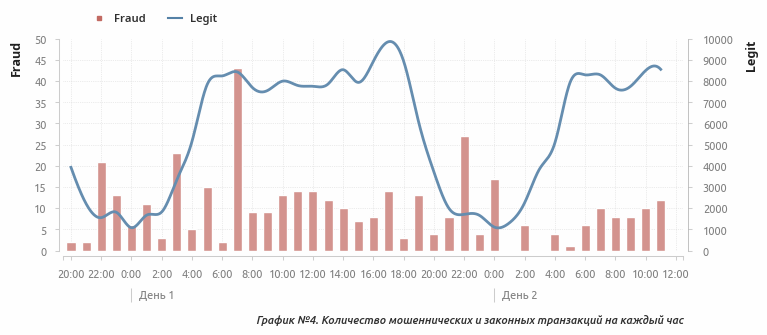

Image 'transactions_overview_per_hour.png' successfully saved into 'docs/img/01-explore' directory


In [67]:
fig, ax1 = plt.subplots(figsize=(8, 2.75))

line1 = ax1.bar(
    x=frauds_target_by_hour_seq.index,
    height=frauds_target_by_hour_seq,
    width=0.025,
    color=alpha_color(palette[1], 0.65),
    zorder=2
)

ax2 = ax1.twinx()

line2 = ax2.plot(
    cleans_target_by_hour_seq_smoothed.index,
    cleans_target_by_hour_seq_smoothed,
    linewidth=2,
    color=alpha_color(palette[2], 0.9),
    zorder=1
)

# ax2.plot(
#     frauds_target_by_hour_seq.index,
#     frauds_target_by_hour_seq,
#     linewidth=0.75,
#     color=palette[1],
#     alpha=0.5
# )

# ax2.scatter(
#     x=frauds_target_by_hour_seq.index,
#     y=frauds_target_by_hour_seq,
#     color=alpha_color(palette[1], 0.8),
#     **scatter
# )

# ax1.tick_params(axis='x', labelsize=7)



# ax1.xaxis.set_major_locator(mpl.dates.HourLocator(byhour=arange(0, 24, 4)))
ax1.xaxis.set_major_locator(mpl.dates.HourLocator(interval=2))
ax1.xaxis.set_major_formatter(mpl.dates.DateFormatter(fmt='%-H:%M'))

# ax1.set_xlim(
#     frauds_target_by_hour_seq.index[0],
#     frauds_target_by_hour_seq.index[-1]
# )

ax1.set_xticks(
    ax1.get_xticks()[1:]
)

ax1.set_ylim(0, 50)
ax1.set_yticks(arange(0, 50, 5, True))

ax2.set_ylim(0, 10000)
ax2.set_yticks(arange(0, 10000, 1000, True))

add_days_labels(ax=ax1)

axis_add_interval_to_first_last_ticks(0.25)

axis_rstyle(
    offset_bottom=4,
    grid=True,
    ax=ax1
)

# axis_hide_every_nth_ticklabel([2], ax=ax1, axis_with_intervals=True)
# axis_hide_every_nth_ticklabel([2], ax=ax1, axis_with_intervals=True)

ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_position(('outward', 3))

ax2.tick_params(
    axis='y',
    direction='out',
    color='#CECECE',
    labelcolor='#808080',
    size=3
)

ax1.set_ylabel('Fraud', **label)
ax2.set_ylabel('Legit', **label)

leg = plt.legend(
    **legend_inline(bbox_to_anchor=(0.03, 1.02)),
    **legend_create_handles(
        2, ['s', 'l'],
        # rectsize=4,
        # linewidth=1.5,
        labels=['Fraud', 'Legit'],
        colors=[alpha_color(palette[1], 0.9), palette[2]],
    ),
    **legend
)

ax1.annotate(
    'График №4. Количество мошеннических и законных транзакций на каждый час',
    xy=(1, -0.3),
    **annotation
)

plt.show()

savefig('transactions_overview_per_hour', dir_save_img, format='png')

##### <font color='#CE4F44'>Variable:</font> FraudPerHundredByHour

In [68]:
fraud_per_hundred_tr_by_hour_map = data.groupby('TimeHour').apply(calculate_fraud_per_transaction)

In [69]:
data['FraudPerHundredByHour'] = data['TimeHour'].map(fraud_per_hundred_tr_by_hour_map)

In [70]:
fraud_per_hundred_by_hour_df = (
    data
    .groupby(['TimeHour', target]).agg(
        Frequency=(target, 'count'),
        FraudPerHundredByHour=('FraudPerHundredByHour', pd.Series.mode)
        )
    .reset_index()
    .pivot(
        index=['TimeHour', 'FraudPerHundredByHour'],
        columns='Class',
        values='Frequency'
        )
    .rename_axis(columns=None)
    .reset_index()
    .rename(columns={0: 'Clean', 1: 'Fraud'})
    )

In [71]:
transactions_total_count = (
    data
    .groupby('TimeHour')[target]
    .count()
    .reset_index()
    # .rename(columns={'TimeHour': 'Hour'})
)

In [72]:
transactions_total_count = (
    pd
    .merge(
        fraud_per_hundred_by_hour_df,
        transactions_total_count,
        on='TimeHour'
    )
    .rename(
        columns={'Class': 'Total'}
    )
)

In [73]:
transactions_total_count = pd_put_columns_last(
    transactions_total_count, 'FraudPerHundredByHour'
)

In [74]:
transactions_total_count_format_mapping = {
    'FraudPerHundredByHour': '{:.3f}'
}

In [75]:
transactions_total_count_format = {'FraudPerHundredByHour': '{:.3f}'}

In [76]:
transactions_total_count

,TimeHour,Clean,Fraud,Total,FraudPerHundredByHour
0,0,2181,23,2204,1.044
1,1,2977,11,2988,0.368
2,2,4073,9,4082,0.220
3,3,7210,23,7233,0.318
4,4,10223,9,10232,0.088
5,5,15751,16,15767,0.101
6,6,16540,8,16548,0.048
7,7,16728,53,16781,0.316
8,8,15361,17,15378,0.111
9,9,15306,17,15323,0.111


##### <font color='#CE4F44'>Variable:</font> TransactionNight

In [77]:
transactions_at_night_mask = (
    (data['TimeHour'].between(0,3)) | (data['TimeHour'].between(21,23))
)

In [78]:
transactions_at_night_mask1 = (
    (data['TimeHour'].between(0,7)) | (data['TimeHour'].between(19,23))
)

In [79]:
data['TransactionNight'] = np.where(transactions_at_night_mask, 1, 0)

In [80]:
data['TransactionNight1'] = np.where(transactions_at_night_mask1, 1, 0)

In [81]:
day_hours = list(np.sort(data.loc[data['TransactionNight'] == 0, 'TimeHour'].unique()))
night_hours = list(np.sort(data.loc[data['TransactionNight'] == 1, 'TimeHour'].unique()))

In [82]:
day_hours

[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [83]:
night_hours

[0, 1, 2, 3, 21, 22, 23]

In [84]:
day_hours1 = list(np.sort(data.loc[data['TransactionNight1'] == 0, 'TimeHour'].unique()))
night_hours1 = list(np.sort(data.loc[data['TransactionNight1'] == 1, 'TimeHour'].unique()))

In [85]:
day_hours1

[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

In [86]:
night_hours1

[0, 1, 2, 3, 4, 5, 6, 7, 19, 20, 21, 22, 23]

##### <font color='#1E82C8'>Variable:</font> Update Cleans and Frauds

In [87]:
cleans, frauds = update_cleans_and_frauds(data)

##### <font color='#40996D'>Variable:</font> Visualization 

In [88]:
data_frauds_per_hundred_hour_plot = data[['TimeHour', 'FraudPerHundredByHour']].drop_duplicates()
data_frauds_per_hundred_hour_plot = data_frauds_per_hundred_hour_plot.sort_values('TimeHour').reset_index()
data_frauds_per_hundred_hour_plot_smoothed = smoothed(data_frauds_per_hundred_hour_plot, n=300, k=2)

In [89]:
hours_night = data.loc[data['TransactionNight']==1, 'TimeHour'].unique()
hours_day = data.loc[data['TransactionNight']==0, 'TimeHour'].unique()

In [90]:
day_values = data_frauds_per_hundred_hour_plot.loc[
    data_frauds_per_hundred_hour_plot['TimeHour'].isin(hours_day),
    'FraudPerHundredByHour'
]

night_values = data_frauds_per_hundred_hour_plot.loc[
    data_frauds_per_hundred_hour_plot['TimeHour'].isin(hours_night),
    'FraudPerHundredByHour'
]

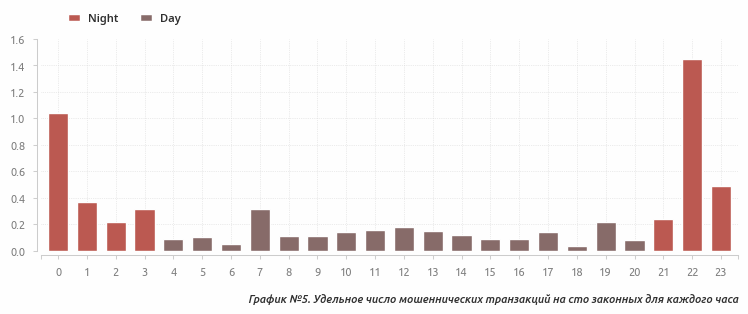

Image 'transactions_fraud_per_100_by_hour.png' successfully saved into 'docs/img/01-explore' directory


In [91]:
day_color = '#876B69'

fig, ax = plt.subplots()
# fig, ax = plt.subplots(figsize=(9.25, 2.75))

ax.bar(
    x=night_values.index,
    height=night_values,
    color=palette[1],
    width=0.7
)

ax.bar(
    x=day_values.index,
    height=day_values,
    color=day_color,
    width=0.7
)

ax.set_xticks(
    data_frauds_per_hundred_hour_plot['TimeHour']
)

axis_add_interval_to_first_last_ticks(0.6)
axis_rstyle(grid=True)

ax.tick_params(
    # bottom=False,
    pad=5
)

leg = plt.legend(
    **legend_inline(bbox_to_anchor=(0.03, 1.02)),
    **legend_create_handles(
        2, ['r', 'r'],
        rectsize=4,
        handlelength=0.5,
        alphas=[1, 1],
        labels=['Night', 'Day'],
        colors=[palette[1], day_color],
    ),
    **legend
)

ax.annotate(
    'График №5. Удельное число мошеннических транзакций на сто законных для каждого часа',
    xy=(1, -0.2),
    **annotation
)

# ax.set_ylabel('Frauds per 100 transactions', **label)
ax.set_xlabel(None)

plt.show()

savefig('transactions_fraud_per_100_by_hour', dir_save_img, format='png')

In [92]:
transactions_total_count.astype(object).loc[day_hours, :].style.format(transactions_total_count_format).hide()

TimeHour,Clean,Fraud,Total,FraudPerHundredByHour
4,10223,9,10232,0.088
5,15751,16,15767,0.101
6,16540,8,16548,0.048
7,16728,53,16781,0.316
8,15361,17,15378,0.111
9,15306,17,15323,0.111
10,16497,23,16520,0.139
11,16348,26,16374,0.159
12,7756,14,7770,0.180
13,7862,12,7874,0.152


In [93]:
transactions_total_count.astype(object).loc[night_hours, :].style.format(transactions_total_count_format).hide()

TimeHour,Clean,Fraud,Total,FraudPerHundredByHour
0,2181,23,2204,1.044
1,2977,11,2988,0.368
2,4073,9,4082,0.220
3,7210,23,7233,0.318
21,4198,10,4208,0.238
22,3260,48,3308,1.451
23,3470,17,3487,0.488


#### Significance of night and day fraud frequencies

Difference in proportions significant (p-value = 0).

##### TransactionNight (21h to 3h)

In [94]:
frauds_night = data.loc[data['TransactionNight']==1, target].values

In [95]:
frauds_day = data.loc[data['TransactionNight']==0, target].values

In [96]:
chi2_test_table = np.array([
    [len(frauds_night[frauds_night==1]), len(frauds_night[frauds_night==0])],
    [len(frauds_day[frauds_day==1]), len(frauds_day[frauds_day==0])]
])

In [97]:
chi2_test_table

array([[   141,  27369],
       [   256, 196270]])

In [98]:
chi2_results = chi2_contingency(chi2_test_table)

In [99]:
chi2_results.pvalue

8.485746658939664e-45

In [100]:
chi2_results.pvalue < 0.0001

True

##### TransactionNight1 (19h to 7h)

In [101]:
frauds_night = data.loc[data['TransactionNight1']==1, target].values

In [102]:
frauds_day = data.loc[data['TransactionNight1']==0, target].values

In [103]:
chi2_test_table = np.array([
    [len(frauds_night[frauds_night==1]), len(frauds_night[frauds_night==0])],
    [len(frauds_day[frauds_day==1]), len(frauds_day[frauds_day==0])]
])

In [104]:
chi2_test_table

array([[   246, 100294],
       [   151, 123345]])

In [105]:
chi2_results = chi2_contingency(chi2_test_table)

In [106]:
chi2_results.pvalue

1.0379936680166446e-11

In [107]:
chi2_results.pvalue < 0.0001

True

#### Resampling

In [108]:
length_resampling = len(frauds)

In [109]:
length_resampling

397

In [110]:
%%time
samples_bootstrap = get_cleans_sample_w_ci(
    df=cleans,
    length=length_resampling,
    n=1000
)

CPU times: user 15.6 s, sys: 222 ms, total: 15.8 s
Wall time: 16 s


In [111]:
samples_bootstrap_smoothed = samples_bootstrap[['ci_min', 'ci_max']].copy()

In [112]:
samples_bootstrap_smoothed = smoothed(samples_bootstrap_smoothed, datetime_index=True)

In [113]:
frauds_by_hour = frauds.groupby(pd.Grouper(key='TimeDatetime', freq='h'))[target].count()

In [114]:
frauds_by_hour_smoothed = smoothed(frauds_by_hour, return_type='series', datetime_index=True)

In [115]:
frauds_by_hour_diff = (samples_bootstrap['statistic'] - frauds_by_hour).to_frame(name='Diff')

In [116]:
frauds_by_hour_diff['Color'] = np.where(
    frauds_by_hour_diff['Diff'] > 0,
    rgb_to_hex(palette[2]),
    rgb_to_hex(palette[1])
)

In [117]:
bars_rouded_delta = 1

frauds_by_hour_diff['Bars_delta'] = np.where(
    frauds_by_hour_diff['Diff'] < 0,
    - bars_rouded_delta,
    + bars_rouded_delta,
)

In [118]:
bars_rouded_delta = 1

/var/folders/2_/z4vwl3gj4l3g3wd030nf35n00000gn/T/ipykernel_2273/1363426481.py:3995: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['День 1', 'День 2'])


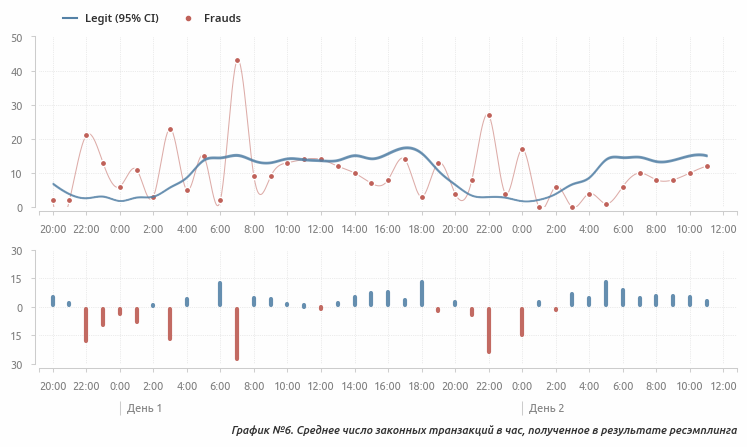

Image 'transactions_simulation_count_per_hour.png' successfully saved into 'docs/img/01-explore' directory


In [119]:
fig, axs = plt.subplots(2, 1, height_ratios=[3,2])
fig.set_figheight(4.25)

fig.subplots_adjust(hspace=0.3)

ax1 = axs[0]
ax2 = axs[1]

ax1.fill_between(
    x=samples_bootstrap_smoothed.index,
    y1=samples_bootstrap_smoothed['ci_min'],
    y2=samples_bootstrap_smoothed['ci_max'],
    color=palette[2],
    edgecolor=palette[2],
    alpha=0.75,
    zorder=2
)

ax1.plot(
    frauds_by_hour_smoothed.index,
    frauds_by_hour_smoothed,
    lw=0.75,
    color=alpha_color(palette[1], 0.5),
    zorder=1,
    # clip_on=False
)

ax1.scatter(
    frauds_by_hour.index,
    frauds_by_hour,
    color=alpha_color(palette[1], 0.95),
    edgecolor='#FFFFFF',
    lw=1,
    s=20,
    **scatter
)

for row in frauds_by_hour_diff.itertuples():
    ax2.plot(
        [row.Index, row.Index],
        [row.Bars_delta, row.Diff],
        lw=3,
        solid_capstyle='round',
        color=alpha_color(row.Color, 0.9)
    )

ax1.xaxis.set_major_locator(mpl.dates.HourLocator(byhour=arange(0, 24, 2)))
ax1.xaxis.set_major_formatter(mpl.dates.DateFormatter(fmt='%-H:%M'))

# ax1.set_xlim(
#     frauds_by_hour.index[0],
#     frauds_by_hour.index[-1]
# )

ax1.set_yticks(arange(0, 50, 10, True))
ax1.set_ylim(0, 50)

axis_add_interval_to_first_last_ticks(scale=0.4, ax=ax1)
axis_rstyle(grid=True, ax=ax1)

ax2.xaxis.set_major_locator(mpl.dates.HourLocator(byhour=arange(0, 24, 2)))
ax2.xaxis.set_major_formatter(mpl.dates.DateFormatter(fmt='%-H:%M'))

ax2.set_yticks(arange(-30, 30, 15, True))

# ax2.set_xlim(
#     frauds_by_hour.index[0],
#     frauds_by_hour.index[-1]
# )

add_days_labels(ax=ax2)

axis_add_interval_to_first_last_ticks(0.4, ax=ax2)
axis_rstyle(grid=True, ax=ax2)

ax2.set_yticklabels([f'{abs(tick):.0f}' for tick in ax2.get_yticks()])

leg = ax1.legend(
    **legend_inline(bbox_to_anchor=(0.02, 1.01)),
    **legend_create_handles(
        2, ['l', 'p'],
        labels=['Legit (95% CI)', 'Frauds'],
        colors=[alpha_color(palette[2], 1), alpha_color(palette[1], 0.95)],
    ),
    **legend
)

ax2.annotate(
    'График №6. Среднее число законных транзакций в час, полученное в результате ресэмплинга',
    xy=(1, -0.54),
    **annotation
)

plt.show()

savefig('transactions_simulation_count_per_hour', dir_save_img, format='png')

In [120]:
%time
bootstrap_fraud_prob = get_cleans_sample_for_probability(
    df=cleans, 
    length=len(frauds),
    n=1000
)

CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 7.87 μs


In [121]:
bootstrap_fraud_prob_smoothed = smoothed(bootstrap_fraud_prob, k=3, n=300)

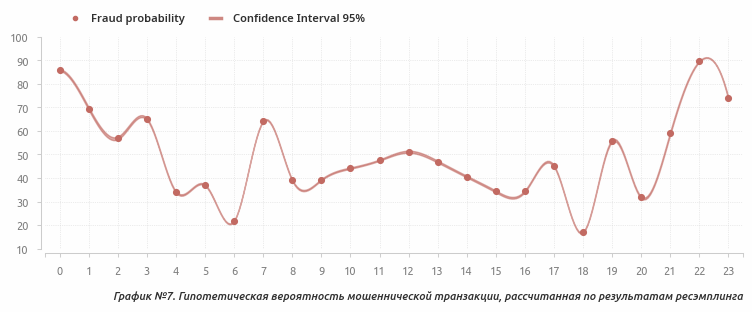

Image 'transactions_simulation_probability_by_hour.png' successfully saved into 'docs/img/01-explore' directory


In [122]:
fig, ax = plt.subplots()

ax.fill_between(
    x=bootstrap_fraud_prob_smoothed.index,
    y1=bootstrap_fraud_prob_smoothed['ci_min'],
    y2=bootstrap_fraud_prob_smoothed['ci_max'],
    color=alpha_color(palette[1], 1),
    edgecolor=alpha_color(palette[1], 1),
    # edgecolor='none',
    alpha=0.5
)

ax.scatter(
    x=bootstrap_fraud_prob.index,
    y=bootstrap_fraud_prob['statistic'],
    linewidths=1,
    # edgecolor=alpha_color(palette[1], 0.9),
    # color=alpha_color(palette[1], 0.5),
    color=alpha_color(palette[1], 0.9),
    s=17
)

ax.set_xlabel(None)
# ax.set_ylabel('Hypothetical probability of fraud', **label)

ax.set_xticks(bootstrap_fraud_prob.index)

axis_add_interval_to_first_last_ticks(0.5)
axis_rstyle()

# percents instead of proportions
ax.yaxis.set_major_formatter(
    mpl.ticker.PercentFormatter(xmax=1.0, symbol='')
)

leg = plt.legend(
    **legend_inline(bbox_to_anchor=(0.02, 1.01)),
    **legend_create_handles(
        2, ['p', 'r'],
        handlelength=1,
        rectsize=2.5,
        # pointsize=4,
        labels=['Fraud probability', 'Confidence Interval 95%'],
        colors=[alpha_color(palette[1], 0.9), alpha_color(palette[1], 0.95)],
    ),
    **legend
)

ax.annotate(
    'График №7. Гипотетическая вероятность мошеннической транзакции, рассчитанная по результатам ресэмплинга',
    xy=(1, -0.2),
    **annotation
)

plt.show()

savefig('transactions_simulation_probability_by_hour', dir_save_img, format='png')

## Amounts variable

In [123]:
data['Amount'].describe()

count    224036.000000
mean         90.848895
std         250.476693
min           0.000000
25%           6.000000
50%          23.450000
75%          79.990000
max       19656.530000
Name: Amount, dtype: float64

/var/folders/2_/z4vwl3gj4l3g3wd030nf35n00000gn/T/ipykernel_2273/1363426481.py:3995: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['День 1', 'День 2'])


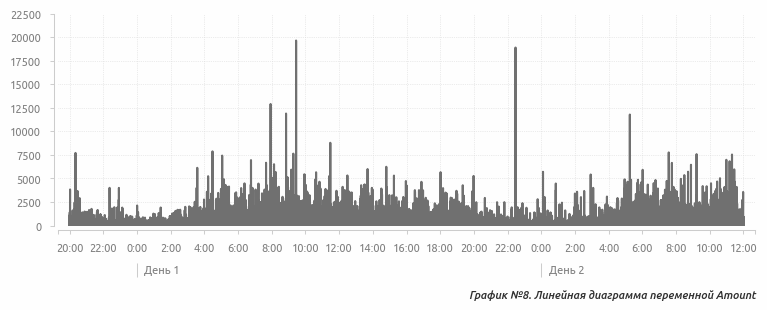

Image 'amount_per_hour.png' successfully saved into 'docs/img/01-explore' directory


In [124]:
fig, ax = plt.subplots()

ax.plot(
    data['TimeDatetime'],
    data['Amount'],
    color=palette[-3]
)

ax.xaxis.set_major_locator(mpl.dates.HourLocator(byhour=arange(0, 24, 2)))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter(fmt='%-H:%M'))

# ax.set_xlim(
#     data['TimeDatetime'].min(),
#     data['TimeDatetime'].max()
# )

add_days_labels(ax=ax)

axis_add_interval_to_first_last_ticks(0.35)
axis_rstyle(ylim=[0, 22500])

ax.annotate(
    'График №8. Линейная диаграмма переменной Amount',
    xy=(1, -0.3),
    **annotation
)

plt.show()

savefig('amount_per_hour', dir_save_img, format='png')

In [125]:
ecdf = sm.distributions.empirical_distribution.ECDF(
    data['Amount'].sort_values()
)

In [126]:
ecdf_plot = ecdf(data['Amount'].sort_values())

In [127]:
ecdf_plot = pd.DataFrame(ecdf_plot, columns=['ECDF'])

In [128]:
ecdf_plot = data['Amount'].sort_values().reset_index(drop=True).to_frame().join(ecdf_plot)

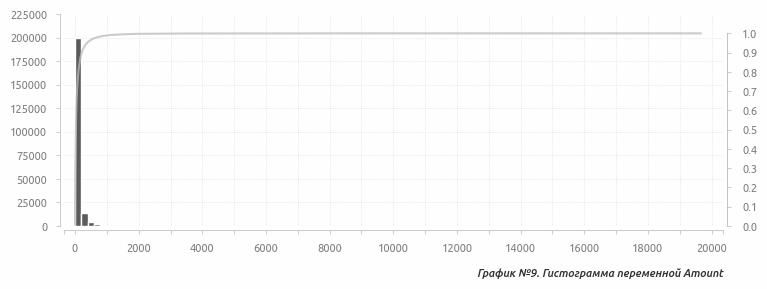

Image 'amount_hist.png' successfully saved into 'docs/img/01-explore' directory


In [129]:
fig, ax = plt.subplots(figsize=(8.5, 2.75))

ax.hist(
    data['Amount'],
    bins=100
)

ax2 = ax.twinx()

ax2.plot(
    ecdf_plot['Amount'],
    ecdf_plot['ECDF'],
    color=palette[-1],
    alpha=0.75
)

ax.set_xticks(arange(0, 20000, 1000, True))

axis_add_interval_to_first_last_ticks(0.35)
axis_rstyle(ax=ax)
axis_hide_every_nth_ticklabel(2, axis_with_intervals=True, ax=ax)

ax2.set_yticks(arange(0, 1, 0.1, True))
ax2.set_ylim(0, 1.1)
ax2.spines['right'].set_bounds(0, 1)

ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_position(('outward', 3))

ax2.tick_params(
    axis='y',
    direction='out',
    color='#CECECE',
    labelcolor='#808080',
    size=3
)

ax.annotate(
    'График №9. Гистограмма переменной Amount',
    xy=(1, -0.2),
    **annotation
)

ax.set_ylabel(None)
ax.set_xlabel(None)

# ax.set_zorder(ax2.get_zorder() + 1)
# ax.patch.set_visible(False)

plt.show()

savefig('amount_hist', dir_save_img, format='png')

In [130]:
ecdf_plot.loc[ecdf_plot['Amount']<500, 'ECDF'].iloc[-1]

0.9654921530468317

In [131]:
ecdf_plot_500 = ecdf_plot.loc[ecdf_plot['Amount'] < 500].copy()

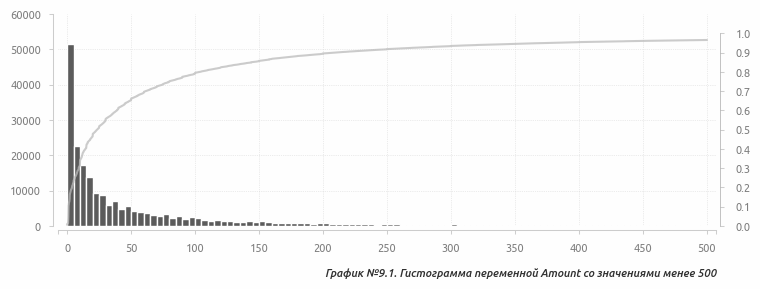

Image 'amount_hist_a.png' successfully saved into 'docs/img/01-explore' directory


In [132]:
fig, ax = plt.subplots(figsize=(8.5, 2.75))

ax.hist(
    data.loc[data['Amount'] < 500, 'Amount'],
    bins=100
)

ax2 = ax.twinx()

ax2.plot(
    ecdf_plot_500['Amount'],
    ecdf_plot_500['ECDF'],
    color=palette[-1],
    alpha=0.75
)

ax.set_xticks(arange(0, 500, 50, True))

axis_add_interval_to_first_last_ticks(0.15)
axis_rstyle(ax=ax)
# axis_hide_every_nth_ticklabel(2, axis_with_intervals=True, ax=ax)

ax2.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1])
ax2.set_yticks(arange(0, 1, 0.1, True))
ax2.set_ylim(0, 1.1)
ax2.spines['right'].set_bounds(0, 1)

ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_position(('outward', 3))

ax2.tick_params(
    axis='y',
    direction='out',
    color='#CECECE',
    labelcolor='#808080',
    size=3
)

ax.annotate(
    'График №9.1. Гистограмма переменной Amount со значениями менее 500',
    xy=(1, -0.2),
    **annotation
)

ax.set_ylabel(None)
ax.set_xlabel(None)

plt.show()

savefig('amount_hist_a', dir_save_img, format='png')

#### Median per hour

##### Trend

In [133]:
amount_median_freq_per_hour = data.groupby(pd.Grouper(key='TimeDatetime', freq='h'))['Amount'].median()
amount_median_freq_per_hour_smoothed = smoothed(amount_median_freq_per_hour, datetime_index=True)

/var/folders/2_/z4vwl3gj4l3g3wd030nf35n00000gn/T/ipykernel_2273/1363426481.py:3995: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['День 1', 'День 2'])


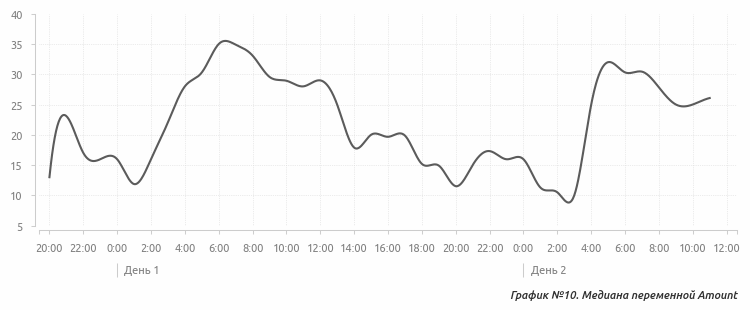

Image 'amount_median_per_hour.png' successfully saved into 'docs/img/01-explore' directory


In [134]:
fig, ax = plt.subplots()

ax.plot(
    amount_median_freq_per_hour_smoothed.index,
    amount_median_freq_per_hour_smoothed['Amount'],
    # linewidth=1.5
)

ax.xaxis.set_major_locator(mpl.dates.HourLocator(byhour=arange(0, 24, 2)))
# ax.xaxis.set_major_locator(mpl.dates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter(fmt='%-H:%M'))

# ax.set_xlim(
#     amount_median_freq_per_hour_smoothed.index[0],
#     amount_median_freq_per_hour_smoothed.index[-1]
# )

add_days_labels(ax=ax)

axis_add_interval_to_first_last_ticks(0.3)
axis_rstyle()

ax.annotate(
    'График №10. Медиана переменной Amount',
    xy=(1, -0.3),
    **annotation
)

plt.show()

savefig('amount_median_per_hour', dir_save_img, format='png')

##### <font color='#CE4F44'>Variable:</font> AmountMedianByHour

In [135]:
data['AmountMedianByHour'] = data.groupby('TimeHour')['Amount'].transform('median')

##### <font color='#1E82C8'>Variable:</font> Update Cleans and Frauds

In [136]:
cleans, frauds = update_cleans_and_frauds(data)

##### <font color='#40996D'>Variable:</font> Visualization 

In [137]:
amount_median_freq_per_hour_cleans = cleans.groupby(pd.Grouper(key='TimeDatetime', freq='h'))['Amount'].median().fillna(0)
amount_median_freq_per_hour_frauds = frauds.groupby(pd.Grouper(key='TimeDatetime', freq='h'))['Amount'].median().fillna(0)

In [138]:
amount_median_freq_per_hour_cleans_smoothed = smoothed(amount_median_freq_per_hour_cleans, datetime_index=True)
amount_median_freq_per_hour_frauds_smoothed = smoothed(amount_median_freq_per_hour_frauds, datetime_index=True)

In [139]:
amount_median_freq_per_hour_frauds_smoothed[amount_median_freq_per_hour_frauds_smoothed < 0] = 0

/var/folders/2_/z4vwl3gj4l3g3wd030nf35n00000gn/T/ipykernel_2273/1363426481.py:3995: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['День 1', 'День 2'])


Image 'amount_frauds_median_per_hour.png' successfully saved into 'docs/img/01-explore' directory


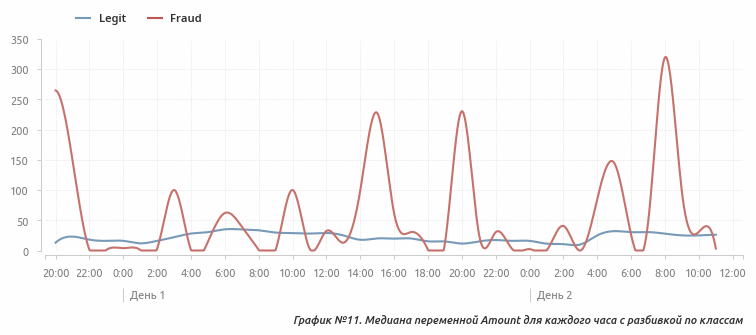

In [140]:
fig, ax = plt.subplots()

ax.plot(
    amount_median_freq_per_hour_cleans_smoothed.index,
    amount_median_freq_per_hour_cleans_smoothed,
    color=alpha_color(palette[2], 0.8),
)

# ax.scatter(
#     amount_median_freq_per_hour_cleans.index,
#     amount_median_freq_per_hour_cleans,
#     color=alpha_color(palette[2], 0.8),
#     s=10
# )

ax.plot(
    amount_median_freq_per_hour_frauds_smoothed.index,
    amount_median_freq_per_hour_frauds_smoothed,
    # color=palette[1],
    color=alpha_color(palette[1], 0.85),
    clip_on=False,
    # lw=2
)

# ax.scatter(
#     amount_median_freq_per_hour_frauds.index,
#     amount_median_freq_per_hour_frauds,
#     color=palette[1],
#     clip_on=False,
#     s=4
# )

ax.xaxis.set_major_locator(mpl.dates.HourLocator(byhour=arange(0, 24, 2)))
# ax.xaxis.set_major_locator(mpl.dates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter(fmt='%-H:%M'))

# ax.set_xlim(
#     amount_median_freq_per_hour_cleans_smoothed.index[0],
#     amount_median_freq_per_hour_cleans_smoothed.index[-1]
# )

ax.set_ylim(
    amount_median_freq_per_hour_frauds.min(),
    amount_median_freq_per_hour_frauds.max()
)

add_days_labels(ax=ax)

axis_add_interval_to_first_last_ticks(0.3)
axis_rstyle(ax=ax)

leg = plt.legend(
    **legend_inline(bbox_to_anchor=(0.03, 1.02)),
    **legend_create_handles(
        2, ['l', 'l'],
        # rectsize=4,
        # handlelength=0.5,
        alphas=[1, 1],
        labels=['Legit', 'Fraud'],
        colors=[alpha_color(palette[2], 0.8), palette[1]],
    ),
    **legend
)

ax.annotate(
    'График №11. Медиана переменной Amount для каждого часа с разбивкой по классам',
    xy=(1, -0.3),
    **annotation
)

savefig('amount_frauds_median_per_hour', dir_save_img, format='png')

plt.show()

##### <font color='#40996D'>Variable:</font> Visualization 

In [141]:
amount_median_by_hour_vis = (
    data[['TimeHour', 'AmountMedianByHour']]
     .copy()
     .drop_duplicates()
     .set_index('TimeHour')
     .sort_index()
     .squeeze()
)

In [142]:
amount_median_by_hour_vis.head()

TimeHour
0    15.95
1    11.85
2    11.85
3    15.00
4    26.26
Name: AmountMedianByHour, dtype: float64

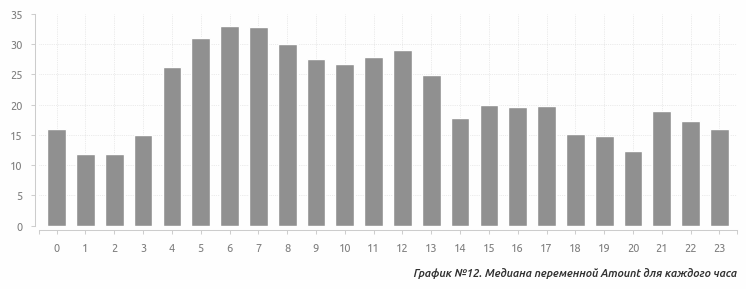

Image 'amount_median_by_hour.png' successfully saved into 'docs/img/01-explore' directory


In [143]:
fig, ax = plt.subplots()

ax.bar(
    x=amount_median_by_hour_vis.index,
    height=amount_median_by_hour_vis,
    width=0.65,
    color=palette[-2]
    # linewidth=1.5
)

ax.set_xticks(
    amount_median_by_hour_vis.index,
    amount_median_by_hour_vis.index
)

axis_add_interval_to_first_last_ticks(0.6)
axis_rstyle()

ax.annotate(
    'График №12. Медиана переменной Amount для каждого часа',
    xy=(1, -0.2),
    **annotation
)

plt.show()

savefig('amount_median_by_hour', dir_save_img, format='png')

In [144]:
cleans_amount_median_by_hour_vis = cleans.groupby('TimeHour')['Amount'].median()
frauds_amount_median_by_hour_vis = frauds.groupby('TimeHour')['Amount'].median()

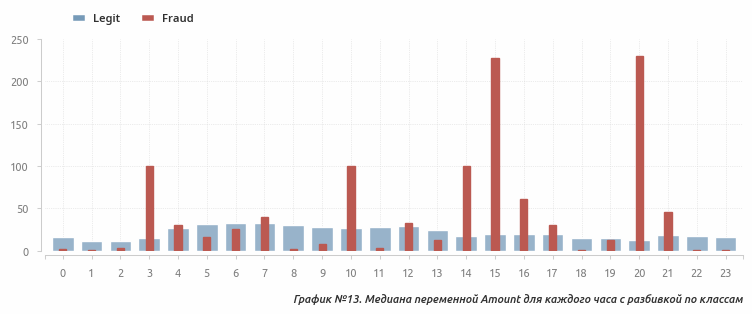

Image 'amount_median_frauds_by_hour.png' successfully saved into 'docs/img/01-explore' directory


In [145]:
fig, ax = plt.subplots()

ax.bar(
    x=cleans_amount_median_by_hour_vis.index,
    height=cleans_amount_median_by_hour_vis,
    width=0.75,
    color=alpha_color(palette[2], 0.6)
)

ax.bar(
    x=frauds_amount_median_by_hour_vis.index,
    height=frauds_amount_median_by_hour_vis,
    width=0.25,
    edgecolor=palette[1],
    color=palette[1]
)

ax.set_xticks(
    amount_median_by_hour_vis.index,
    amount_median_by_hour_vis.index
)

axis_add_interval_to_first_last_ticks(0.6)
axis_rstyle()

leg = plt.legend(
    **legend_inline(bbox_to_anchor=(0.03, 1.02)),
    **legend_create_handles(
        2, ['r', 'r'],
        rectsize=4,
        handlelength=0.5,
        alphas=[1, 1],
        labels=['Legit', 'Fraud'],
        colors=[alpha_color(palette[2], 0.8), palette[1]],
    ),
    **legend
)

ax.annotate(
    'График №13. Медиана переменной Amount для каждого часа с разбивкой по классам',
    xy=(1, -0.2),
    **annotation
)

plt.show()

savefig('amount_median_frauds_by_hour', dir_save_img, format='png')

##### <font color='#CE4F44'>Variable:</font> AmountFracMedianByHour

In [146]:
data['AmountFracMedianByHour'] = data['Amount'] / data['AmountMedianByHour']

##### <font color='#1E82C8'>Variable:</font> Update Cleans and Frauds

In [147]:
cleans, frauds = update_cleans_and_frauds(data)

##### <font color='#3E9C62'>Variable:</font> Visualization 

In [148]:
cleans_plot = cleans.groupby('TimeHour')['AmountFracMedianByHour'].mean()
frauds_plot = frauds.groupby('TimeHour')['AmountFracMedianByHour'].mean()

In [149]:
cleans_plot_smoothed = smoothed(cleans_plot)
frauds_plot_smoothed = smoothed(frauds_plot, return_type='series')

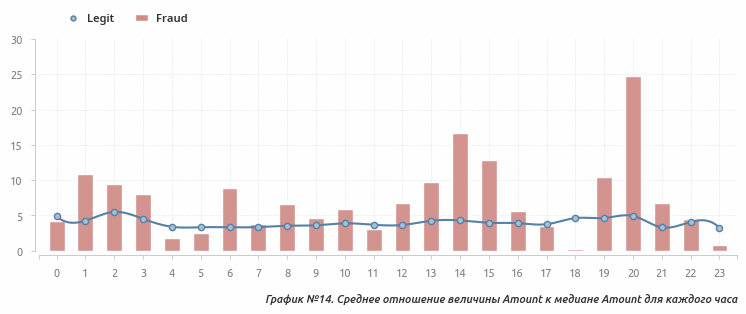

Image 'amount_frac_median_by_hour.png' successfully saved into 'docs/img/01-explore' directory


In [150]:
fig, ax = plt.subplots()

ax.bar(
    x=frauds_plot.index,
    height=frauds_plot,
    width=0.55,
    color=alpha_color(palette[1], 0.65)
)

ax.plot(
    cleans_plot_smoothed,
    color=palette[2],
    zorder=1
)

ax.scatter(
    x=cleans_plot.index,
    y=cleans_plot,
    # color=palette[2],
    edgecolor=palette[2],
    facecolor=alpha_color(palette[2], 0.5),
    s=20,
    zorder=2
)

ax.set_xticks(arange(0, 23, 1, True))

axis_add_interval_to_first_last_ticks(0.6)
axis_rstyle()

leg = plt.legend(
    **legend_inline(bbox_to_anchor=(0.03, 1.02)),
    **legend_create_handles(
        2, ['p', 'r'],
        edgecolor=palette[2],
        edgewidth=1,
        linewidth=3,
        markersize=3.5,
        rectsize=4,
        handlelength=0.5,
        alphas=[1, 1],
        labels=['Legit', 'Fraud'],
        colors=[alpha_color(palette[2], 0.5), alpha_color(palette[1], 0.7)],
    ),
    **legend
)

ax.annotate(
    'График №14. Среднее отношение величины Amount к медиане Amount для каждого часа',
    xy=(1, -0.2),
    **annotation
)

plt.show()

savefig('amount_frac_median_by_hour', dir_save_img, format='png')

#### Discretization

##### <font color='#CE4F44'>Variable:</font> AmountCategory

In [151]:
# find number of categories and add additional for Amount == 0
zero_category = (
    np.log(data.loc[data['Amount'] != 0, 'Amount'])
    .round()
    .sort_values()
    .unique()
    .min()
    - 1
)

In [152]:
zero_category

-6.0

In [153]:
data['AmountCategory'] = np.where(data['Amount'] != 0, np.log(data['Amount']), zero_category)
data['AmountCategory'] = data['AmountCategory'].round()
data['AmountCategory'] -= data['AmountCategory'].min()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [154]:
data['AmountCategory'].sort_values().unique()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16.])

##### <font color='#CE4F44'>Variable:</font> FraudPerHundredByCategory

In [155]:
fraud_per_hundred_tr_by_category_map = data.groupby('AmountCategory').apply(calculate_fraud_per_transaction)

In [156]:
data['FraudPerHundredByCategory'] = data['AmountCategory'].map(fraud_per_hundred_tr_by_category_map)

##### <font color='#1E82C8'>Variable:</font> Update Cleans and Frauds

In [157]:
cleans, frauds = update_cleans_and_frauds(data)

In [158]:
amount_category_description = (
    data
    .groupby('AmountCategory')
    .agg(
        AmountMin=('Amount', 'min'),
        AmountMax=('Amount', 'max'),
        Frequency=('Amount', 'count')
    )
    # .rename_axis('Category')
    .reset_index()
)

In [159]:
amount_category_description_cleans = (
    cleans
    .groupby('AmountCategory')
    .agg(
        AmountMin=('Amount', 'min'),
        AmountMax=('Amount', 'max'),
        Frequency=('Amount', 'count')
    )
    # .rename_axis('Category')
    .reset_index()
)

In [160]:
amount_category_description_frauds = (
    frauds
    .groupby('AmountCategory')
    .agg(
        AmountMin=('Amount', 'min'),
        AmountMax=('Amount', 'max'),
        Frequency=('Amount', 'count')
    )
    # .rename_axis('Category')
    .reset_index()
)

In [161]:
amount_category_description_cleans_frauds = (
    pd.merge(
        amount_category_description,
        amount_category_description_cleans[['AmountCategory', 'Frequency']],
        how='outer',
        on='AmountCategory',
        suffixes=('', 'Clear')
    )
)

In [162]:
amount_category_description_cleans_frauds = (
    pd.merge(
        amount_category_description_cleans_frauds,
        amount_category_description_frauds[['AmountCategory', 'Frequency']],
        how='outer',
        on='AmountCategory',
        suffixes=('', 'Fraud')
    )
)

In [163]:
amount_category_description_cleans_frauds = amount_category_description_cleans_frauds.fillna(0)

for col in ['AmountCategory', 'FrequencyFraud']:
    amount_category_description_cleans_frauds[col] = amount_category_description_cleans_frauds[col].astype(int)

In [164]:
amount_category_description_cleans_frauds = pd.merge(
    amount_category_description_cleans_frauds,
    data[['AmountCategory', 'FraudPerHundredByCategory']].drop_duplicates(),
    how='left',
    on='AmountCategory'
)

In [165]:
amount_category_columns_format = {
    'AmountMin': '{:.2f}',
    'AmountMax': '{:.2f}',
    'FraudPerHundredByCategory': '{:.3f}'
}

In [166]:
(
    amount_category_description_cleans_frauds
    .style
    .set_table_styles(pd_df_column_names_styles)
    # .set_properties(**pd_df_font_styles)
    .format(amount_category_columns_format)
    .hide()
)

AmountCategory,AmountMin,AmountMax,Frequency,FrequencyClear,FrequencyFraud,FraudPerHundredByCategory
0,0.00,0.00,1537,1518,19,1.236
1,0.01,0.01,619,615,4,0.646
2,0.02,0.03,77,77,0,0.000
3,0.04,0.08,62,62,0,0.000
4,0.09,0.22,256,255,1,0.391
5,0.23,0.60,293,293,0,0.000
6,0.61,1.64,25452,25326,126,0.495
7,1.65,4.48,19589,19572,17,0.087
8,4.49,12.18,36640,36610,30,0.082
9,12.19,33.11,42972,42946,26,0.061


##### <font color='#40996D'>Variable:</font> Visualization 

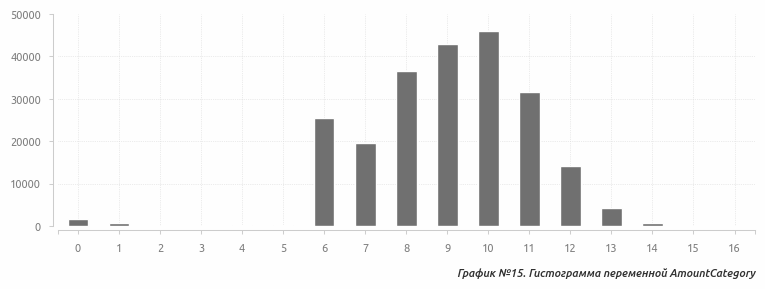

Image 'amount_categories.png' successfully saved into 'docs/img/01-explore' directory


In [167]:
fig, ax = plt.subplots()

ax.bar(
    x=amount_category_description_cleans_frauds['AmountCategory'],
    height=amount_category_description_cleans_frauds['Frequency'],
    width=0.5,
    color=palette[-3]
)

ax.set_xticks(amount_category_description_cleans_frauds['AmountCategory'])

axis_add_interval_to_first_last_ticks(0.5)
axis_rstyle()

ax.annotate(
    'График №15. Гистограмма переменной AmountCategory',
    xy=(1, -0.2),
    **annotation
)

plt.show()

savefig('amount_categories', dir_save_img, format='png')

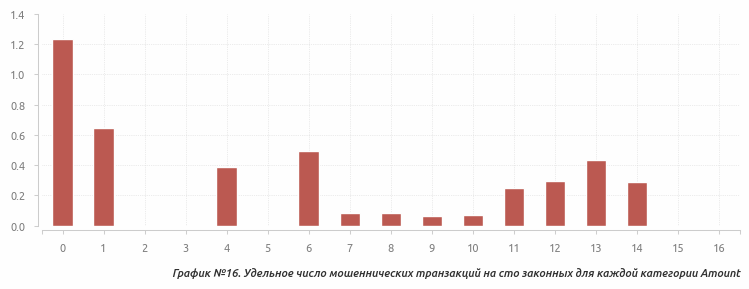

Image 'amount_categories_frac_fraud.png' successfully saved into 'docs/img/01-explore' directory


In [168]:
fig, ax = plt.subplots()

ax.bar(
    x=amount_category_description_cleans_frauds['AmountCategory'],
    height=amount_category_description_cleans_frauds['FraudPerHundredByCategory'],
    width=0.5,
    color=palette[1]
)

ax.set_xticks(amount_category_description_cleans_frauds['AmountCategory'])

axis_add_interval_to_first_last_ticks(0.5)
axis_rstyle()

ax.annotate(
    'График №16. Удельное число мошеннических транзакций на сто законных для каждой категории Amount',
    xy=(1, -0.2),
    **annotation
)

plt.show()

savefig('amount_categories_frac_fraud', dir_save_img, format='png')

#### Amount fraud transactions values common

In [169]:
frauds_common_amounts = frauds['Amount'].value_counts().reset_index(name='FraudFrequency')

In [170]:
merge_df = data.loc[data['Amount'].isin(frauds_common_amounts['Amount']), 'Amount'].value_counts().reset_index(name='TotalFrequency')

In [171]:
frauds_common_amounts = pd.merge(frauds_common_amounts, merge_df, how='left', on='Amount')

In [172]:
frauds_common_amounts['FraudPerHundred'] = (
    100 * 
    frauds_common_amounts['FraudFrequency'] /
    frauds_common_amounts['TotalFrequency']
).round(3)

In [173]:
len(frauds_common_amounts)

219

In [174]:
frauds_common_amounts_columns_format = {
    'Amount': '{:.2f}',
    'FraudPerHundred': '{:.3f}'
}

In [175]:
(
    frauds_common_amounts
    .head(10)
    .style
    .set_table_styles(pd_df_column_names_styles)
    # .set_properties(**pd_df_font_styles)
    .format(frauds_common_amounts_columns_format)
    .hide()
)

Amount,FraudFrequency,TotalFrequency,FraudPerHundred
1.00,97,10952,0.886
99.99,27,303,8.911
0.00,19,1537,1.236
0.76,13,2257,0.576
3.79,4,144,2.778
0.01,4,619,0.646
0.68,3,63,4.762
2.00,3,838,0.358
2.28,3,313,0.958
1.10,2,20,10.000


In [176]:
len(data.loc[data[target]==1]) / len(data) * 100

0.17720366369690585

##### <font color='#CE4F44'>Variable:</font> AmountNightyNine

In [177]:
con_99 = data['Amount'] == 99.99

In [178]:
data['AmountNightyNine'] = np.where(con_99, 1, 0)

##### <font color='#1E82C8'>Variable:</font> Update Cleans and Frauds

In [179]:
cleans, frauds = update_cleans_and_frauds(data)

#### Integer amounts

##### <font color='#CE4F44'>Variable:</font> AmountNightyNine

In [180]:
data['AmountInteger'] = (data['Amount'] % 1 == 0).astype(int)

In [181]:
data_integer = data.loc[data['AmountInteger'] == 1].copy()
data_non_integer = data.loc[data['AmountInteger'] == 0].copy()

In [182]:
assert len(data) == len(data_integer) + len(data_non_integer)

In [183]:
100 * len(data_integer.loc[data_integer[target] == 1]) / len(data_integer)

0.24777268174389794

In [184]:
100 * len(data_non_integer.loc[data_non_integer[target] == 1]) / len(data_non_integer)

0.15317509229397652

In [185]:
chi2_test_table = [
    [len(data_integer.loc[data_integer[target] == 1]), len(data_integer)],
    [len(data_non_integer.loc[data_non_integer[target] == 1]), len(data_non_integer)]
]

In [186]:
chi2_test_table

[[141, 56907], [256, 167129]]

In [187]:
integer_p = chi2_contingency(chi2_test_table).pvalue

In [188]:
integer_p < 0.0001

True

In [189]:
integer_p

4.940991470641954e-06

##### <font color='#1E82C8'>Variable:</font> Update Cleans and Frauds

In [190]:
cleans, frauds = update_cleans_and_frauds(data)

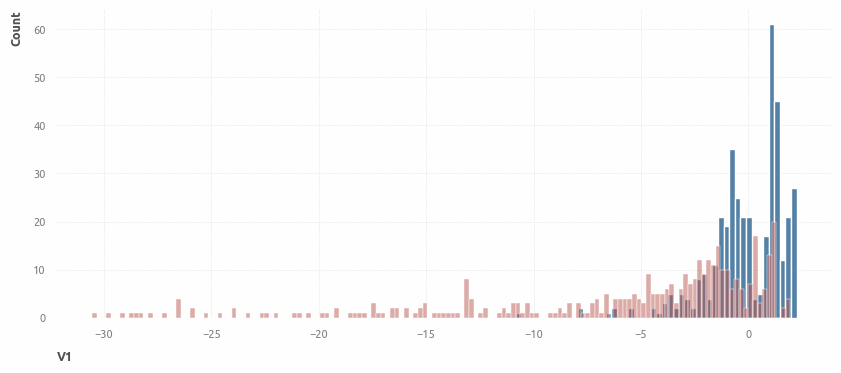

In [65]:
plt.figure(figsize=(10,4))

sns.histplot(
    data=cleans_sample['V1'],
    bins=50,
    alpha=1
)

sns.histplot(
    data=frauds['V1'],
    bins=150,
    color=palette[1],
    alpha=0.5
)

plt.show()

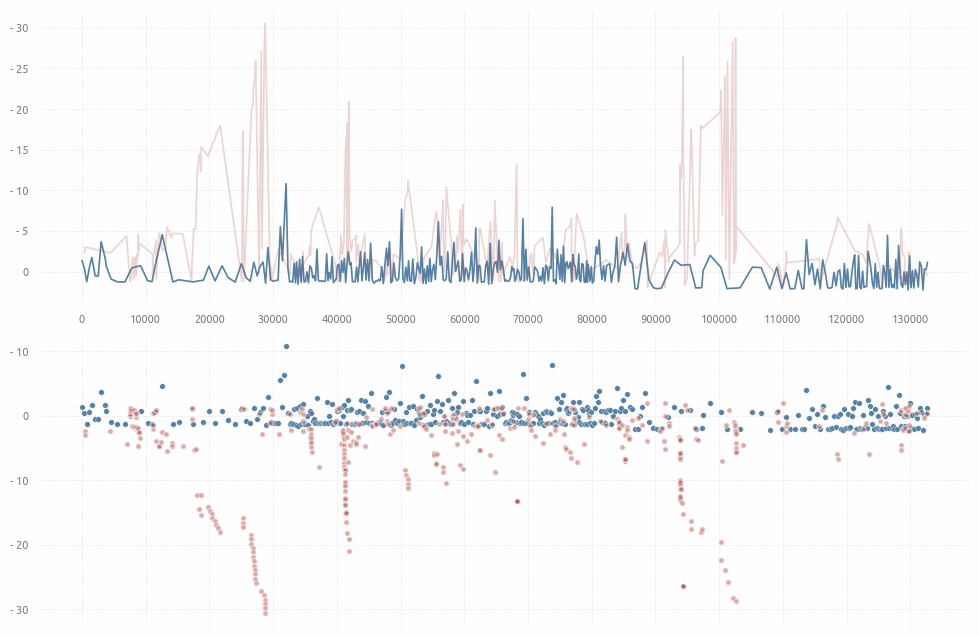

In [66]:
fig, axs = plt.subplots(2,1, figsize=(12,8))

axs[0].plot(
    cleans_sample['Time'],
    -cleans_sample['V1'],
)

axs[0].plot(
    frauds['Time'],
    -frauds['V1'],
    color=palette[1],
    alpha=0.25
)

axs[1].scatter(
    cleans_sample['Time'],
    -cleans_sample['V1'],
    # s=60,
    alpha=1,
    **scatter
)

axs[1].scatter(
    data=frauds,
    x='Time',
    y='V1',
    # s=50,
    alpha=0.5
)

# axs[0].set_yticks(ticks=cleans_sample['V1'])
axs[0].set_xticks(ticks=arange(0, frauds['Time'].max(), 10000))
axs[1].set_xticks(ticks=arange(0, frauds['Time'].max(), 10000))
axs[1].tick_params(labelbottom=False)
plt.subplots_adjust(hspace=0.1)

def change_sign(x, pos):
    if x != 0:
        return f'- {x:.0f}'
    else:
        return int(x)

def nochange_sign(x, pos):
    if x != 0:
        return f'- {abs(x):.0f}'
    else:
        return int(x)
    
axs[0].yaxis.set_major_formatter(ticker.FuncFormatter(change_sign))
axs[1].yaxis.set_major_formatter(ticker.FuncFormatter(nochange_sign))

plt.show()

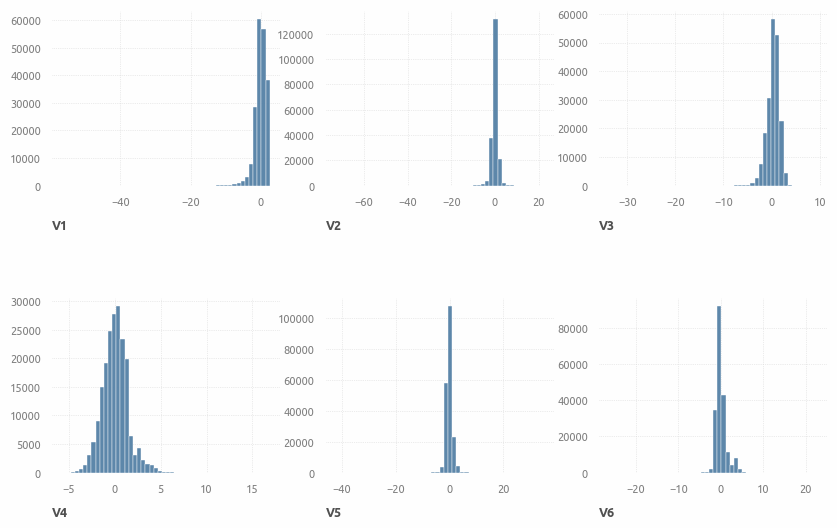

In [30]:
f = plot_gridplot(
    data=data.iloc[:, 1:7],
    features=data.iloc[:, 1:7].columns,
    figsize=(10,6),
    ncols=3,
    kind='hist',
    plot_shape='rectangle',
    hscale=1.6,
    histplot_kwargs={'bins': 50})

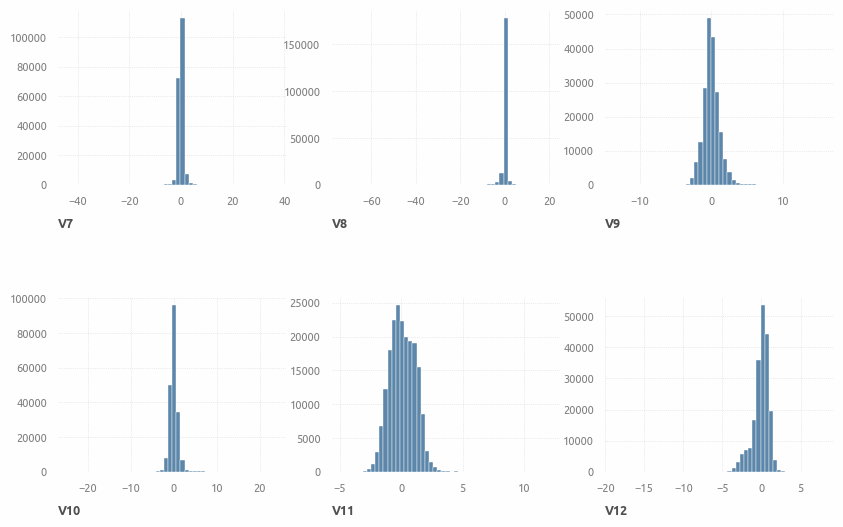

In [31]:
f = plot_gridplot(
    data=data.iloc[:, 7:13],
    features=data.iloc[:, 7:13].columns,
    figsize=(10,6),
    ncols=3,
    kind='hist',
    plot_shape='rectangle',
    hscale=1.6,
    histplot_kwargs={'bins': 50})

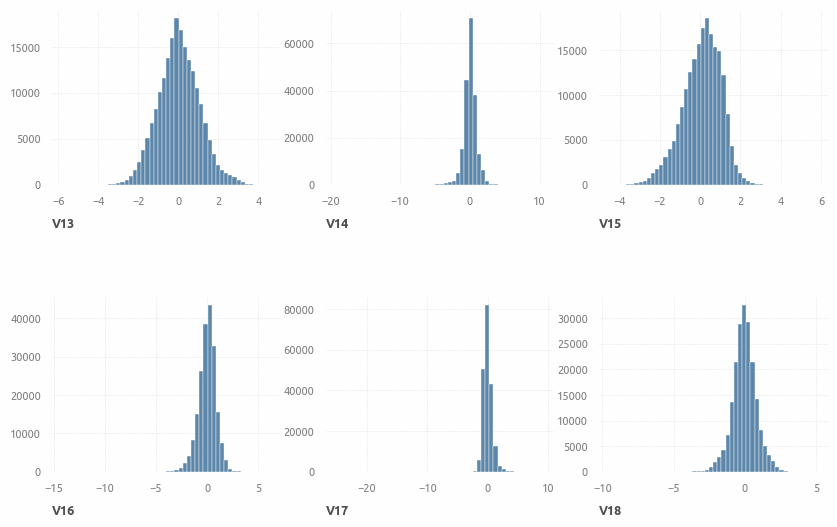

In [32]:
f = plot_gridplot(
    data=data.iloc[:, 13:19],
    features=data.iloc[:, 13:19].columns,
    figsize=(10,6),
    ncols=3,
    kind='hist',
    plot_shape='rectangle',
    hscale=1.6,
    histplot_kwargs={'bins': 50})

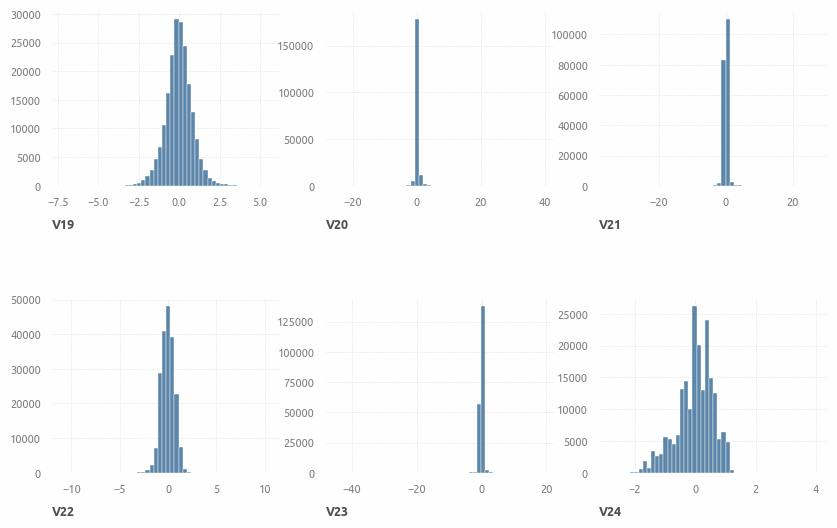

In [33]:
f = plot_gridplot(
    data=data.iloc[:, 19:25],
    features=data.iloc[:, 19:25].columns,
    figsize=(10,6),
    ncols=3,
    kind='hist',
    plot_shape='rectangle',
    hscale=1.6,
    histplot_kwargs={'bins': 50})

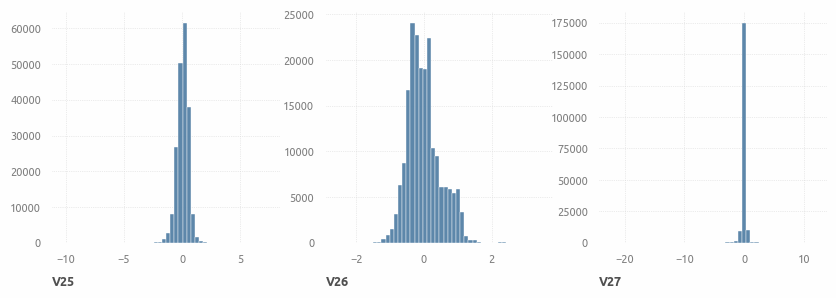

In [34]:
f = plot_gridplot(
    data=data.iloc[:, 25:28],
    features=data.iloc[:, 25:28].columns,
    figsize=(10,3),
    ncols=3,
    kind='hist',
    plot_shape='rectangle',
    hscale=1.6,
    histplot_kwargs={'bins': 50})

### Execution time

In [121]:
stopwatch_stop(start)

Execution time: 0:03:35
